<a href="https://colab.research.google.com/github/ErickEA1995/Projects/blob/main/ODEfitToData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.integrate

Fit ODE to data and convert the abm to this.
Look

In [ ]:
def SIRODE(y, t, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I
    dIdt = beta * S * I - gamma * I
    dRdt = gamma * I

    return [dSdt, dIdt, dRdt]

In [ ]:
def Simulation(initial_conditions, beta, gamma, time):
   time = np.linspace(0, time, time + 1)
   y = scipy.integrate.odeint(SIRODE, initial_conditions, time, args=(beta, gamma))

   return time, y





In [ ]:
def WLS(obs, pred):
    weights = 1/(pred **2)
    return np.sum(weights * (obs - pred)**2)


def ObjectiveFunction(param, *args):
    #Extract beta and gamma
    beta, gamma = param
    initial_conditions, obs, time_steps = args

    time, pred = Simulation(initial_conditions, beta, gamma, time_steps)


    pred_S = pred[:, 0]
    pred_I = pred[:, 1]

    cost = WLS(obs, pred_I)
    '''
    final_susceptible = 251
    cum_dif = 0
    for t in time:
        if pred_S[int(t)] < final_susceptible:
           cum_dif += abs(pred_S[int(t)] - final_susceptible)/final_susceptible

    cost += cum_dif/final_susceptible
    '''
    return cost

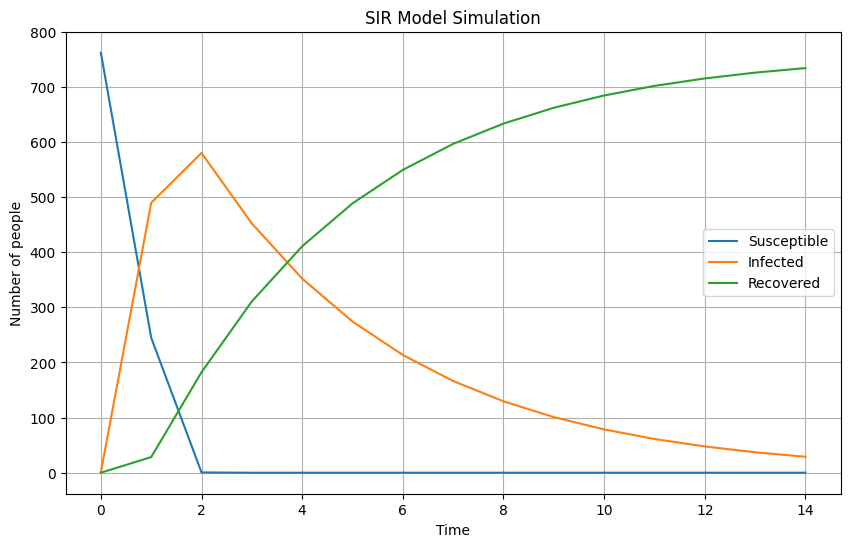

   Time  Susceptible    Infected   Recovered
0   0.0   762.000000    1.000000    0.000000
1   1.0   244.892884  489.728975   28.378141
2   2.0     0.517373  580.109165  182.373463
3   3.0     0.003041  452.208258  310.788701
4   4.0     0.000056  352.182602  410.817342


In [ ]:
initial_pop = 763 #@param{type:"integer"}
initial_infected = 1 #@param{type:"integer"}
beta = .01 #@param{type:"number"}
gamma = .25 #@param{type:"number"}
time_steps = 14 #@param{type:"integer"}

initial_conditions = [initial_pop - initial_infected, initial_infected, 0]


# Run the simulation
time, results = Simulation(initial_conditions, beta, gamma, time_steps)

# Extract results
S, I, R = results.T

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(time, S, label='Susceptible')
plt.plot(time, I, label='Infected')
plt.plot(time, R, label='Recovered')
plt.xlabel('Time')
plt.ylabel('Number of people')
plt.title('SIR Model Simulation')
plt.legend()
plt.grid(True)
plt.show()

# You can also create a pandas DataFrame from the results
df = pd.DataFrame({'Time': time, 'Susceptible': S, 'Infected': I, 'Recovered': R})
print(df.head())

In [ ]:
#Code to upload boarding school data

from google.colab import files

uploaded = files.upload()

import pandas as pd

file_name = list(uploaded.keys())[0]
data_df = pd.read_csv('flu_outbreak_british_boarding_school.csv')

print(data_df)

Saving flu_outbreak_british_boarding_school.csv to flu_outbreak_british_boarding_school.csv
         date  in_bed  convalescent
0   1/22/1978       3             0
1   1/23/1978       8             0
2   1/24/1978      26             0
3   1/25/1978      76             0
4   1/26/1978     225             9
5   1/27/1978     298            17
6   1/28/1978     258           105
7   1/29/1978     233           162
8   1/30/1978     189           176
9   1/31/1978     128           166
10   2/1/1978      68           150
11   2/2/1978      29            85
12   2/3/1978      14            47
13   2/4/1978       4            20


In [ ]:
import numpy as np


# Define the grid search parameters
# Example range for initial infected
beta_grid = np.linspace(0,1,100)  # Example range for beta
gamma_grid = np.linspace(1,5,5) # Example range for gamma

# Assuming 'data_df' contains the observed infected data, replace 'Infected' with the actual column name
observed_infected = data_df['in_bed']
time_steps = len(observed_infected) - 1 # Adjust time steps based on data length

best_cost = float('inf')
best_params = None

# Perform the grid search
for beta_val in beta_grid:
    for gamma_val in gamma_grid:
        initial_conditions = [760, 3, 0]

        # Calculate the cost for the current set of parameters
        current_cost = ObjectiveFunction([beta_val, gamma_val], initial_conditions, observed_infected, time_steps)

        # Check if this is the best cost found so far
        if current_cost < best_cost:
           best_cost = current_cost
           best_params = { 'beta': beta_val, 'gamma': gamma_val}

print("Best parameters found:", best_params)
print("Best WLS cost:", best_cost)

Best parameters found: {'beta': np.float64(0.010101010101010102), 'gamma': np.float64(1.0)}
Best WLS cost: 4141020.712334967


In [ ]:
# prompt: How is my minimize call wrong?

from scipy.optimize import minimize

initial_conditions = [ 760, 3, 0]
# Define the initial guess for beta and gamma
initial_guess = [0.01, 1]  # You'll likely need to adjust these initial values

# Define the bounds for beta and gamma (optional, but recommended)
bounds = [(0, .5), (0, .5)]  # Example bounds: beta and gamma between 0 and 1

# Assuming 'df' contains your observational data with a column named 'Infected'
# You need to extract the observed infected data
obs_I = data_df['in_bed']

# Assuming you want to minimize over the same time steps as the simulation
# If your observed data has different time steps, you'll need to handle that
# (e.g., interpolate or simulate over the observed data's time steps)
time_steps_obs = len(obs_I) - 1 # Assuming time_steps_obs is based on the length of your observed data

# Pass the fixed initial conditions, observed data, and time steps to the objective function
# Wrap the initial conditions, observed data, and time steps into args
args = (initial_conditions, obs_I, time_steps_obs)

# Perform the minimization
result = minimize(ObjectiveFunction, initial_guess, args=args, bounds=bounds, method='L-BFGS-B') # You can choose a different method

# Print the results
print("Optimization Result:")
print(result)

# Extract the optimized beta and gamma
optimized_beta, optimized_gamma = result.x
print(f"Optimized Beta: {optimized_beta}")
print(f"Optimized Gamma: {optimized_gamma}")

Optimization Result:
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 1.344928833957027
        x: [ 2.246e-03  5.000e-01]
      nit: 15
      jac: [ 1.016e-02 -1.705e-02]
     nfev: 114
     njev: 38
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>
Optimized Beta: 0.0022460232721603066
Optimized Gamma: 0.5


Final Susceptible: 30.806609940488734 
[[760.           3.           0.        ]
 [750.15698748   9.94100962   2.9020029 ]
 [719.08676699  31.59448139  12.31875162]
 [633.75412764  88.80609541  40.43977696]
 [466.48372578 187.85860508 108.65766914]
 [277.93273263 261.12940197 223.9378654 ]
 [153.82927488 253.54772667 355.62299844]
 [ 92.00537263 200.94797599 470.04665138]
 [ 62.51373776 144.40740725 556.07885498]
 [ 47.6821844   98.94828763 616.36952796]
 [ 39.69993532  66.14549689 657.15456779]
 [ 35.15377365  43.61767102 684.22855534]
 [ 32.45510426  28.53507871 702.00981703]
 [ 30.80660994  18.57896136 713.6144287 ]]


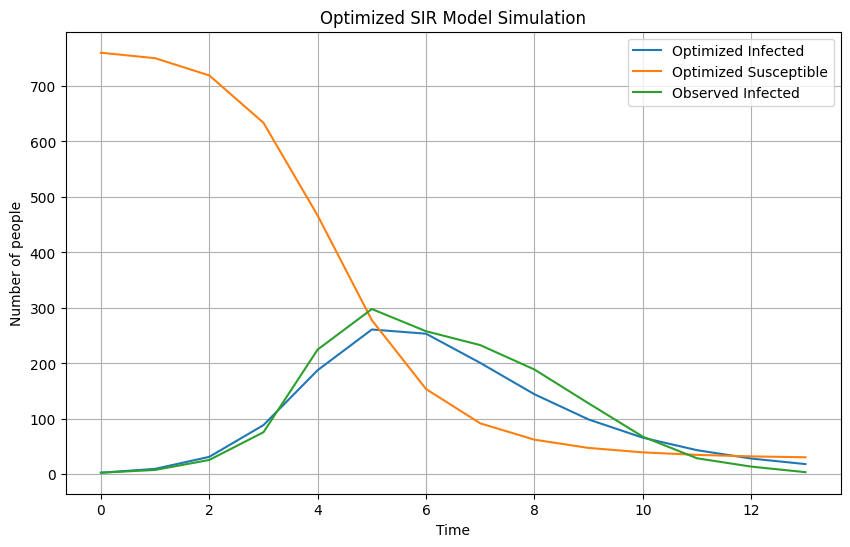

In [ ]:
time, optimized_simulation = Simulation(initial_conditions, optimized_beta, optimized_gamma, time_steps)


print(f"Final Susceptible: {optimized_simulation[13,0]} ")
print(optimized_simulation)
plt.figure(figsize=(10, 6))
plt.plot(time, optimized_simulation[:, 1], label='Optimized Infected' )
plt.plot(time, optimized_simulation[:,0], label='Optimized Susceptible')
plt.plot(time, data_df['in_bed'], label='Observed Infected')
plt.xlabel('Time')
plt.ylabel('Number of people')
plt.title('Optimized SIR Model Simulation')
plt.legend()
plt.grid(True)
plt.show()